In [1]:
import numpy as np
import pandas as pd
import os

## Funções e Configurações

In [2]:
# this dictionary contains the configuration necessary to divide each dataset used in the work, the script is made
# for the conll type of datasets, so if you want to add datasets to divide, make sure to add it here
gen_config = {
    'leNER':{
        'base_dir': "../Base de Dados/leNER/",
        'load_dir': "documents/allDoc/",
        'save_dir': "divisions/iterative/",
        'col_sep' : ' ',
        'file_type': '.conll',
    },
    'UlyssesNER-BR':{
        'base_dir': "../Base de Dados/UlyssesNER-BR/",
        'load_dir': "PL_Corpus_byTypes_conll/",
        'save_dir': "divisions/iterative/",
        'col_sep' : ' ',
        'file_type': '.conll',
    },
    'Harem-second':{
        'base_dir': "../Base de Dados/HAREM/",
        'load_dir': "SecondHarem/documents",
        'save_dir': "divisions/second/iterative/",
        'col_sep' : '\t',
        'file_type': '.conll',
    }
}

In [3]:
def get_sentencas(corpus, coll_sep):
        sentenca = []
        for line in corpus:
            if line == '\n':
                if sentenca:
                    yield sentenca
                    sentenca = []
            else:
                
                sentenca.append(line.strip('\n').split(coll_sep))
        if sentenca:
            yield sentenca

In [4]:
def read_dataset(filepath, coll_sep):
    data_por_sentenca = []
    
    with open(filepath, "r", encoding="utf-8") as corpus:
        data_por_sentenca += list(get_sentencas(corpus, coll_sep))
    
    return data_por_sentenca

In [5]:
def get_data(config, selective = False, fileName = ""):
    load_dir = config['base_dir'] + config['load_dir']
    sep = config['col_sep']
    if selective:
        fp = load_dir + fileName
        return read_dataset(filepath=fp, coll_sep=sep)
    else:
        filepaths = []
        for file in os.listdir(load_dir):
            if file.endswith(config['file_type']):
                filepaths.append(load_dir + file)
        
        data_por_sentenca = []
        for filepath in filepaths:
            print(filepath+"\n")
            data_por_sentenca += read_dataset(filepath=filepath, coll_sep=sep)
        
        return data_por_sentenca

In [6]:
def split_token_label(data):
    return list(map(list,zip(*data)))

## Carregando DataSet e preparando dados

In [7]:
# dataset = 'leNER'
# dataset = 'Paramopama'
# dataset = 'Harem-mini'
dataset = 'Harem-second'
# dataset = 'UlyssesNER-BR'

config = gen_config[dataset]

filepaths = []

files = os.listdir(config['base_dir'] + config['load_dir'])
print(files)
for file in files:
    # if file.endswith('.conll'):
    filepaths.append(config['base_dir'] + config['load_dir'] + file)

# data_por_sentenca = get_data(config=config)

# data_por_sentenca = get_data(config=config, selective=True, fileName='corpus_Paramopama.txt')
# data_por_sentenca = get_data(config=config, selective=True, fileName='haremMini-total.colnn')
# data_por_sentenca = get_data(config=config, selective=True, fileName='primeiroHAREM-total.colnn')
folder_path = '../Base de Dados/HAREM/SecondHarem/documents'
data_por_sentenca_por_doc = {}

# Listar arquivos dentro da pasta
if os.path.exists(folder_path):
    for file in os.listdir(folder_path):
        filepath = os.path.join(folder_path, file)
        
        # Verificar se é um arquivo
        if os.path.isfile(filepath):
            data_por_sentenca_por_doc[file] = read_dataset(filepath, coll_sep=config['col_sep'])
else:
    print(f"O diretório {folder_path} não existe. Verifique o caminho.")

# Exibir resultado
total_documentos = len(data_por_sentenca_por_doc)
print("Total de documentos carregados:", total_documentos)


['2ght33', '2ght33-2', 'aa13183', 'aa25258', 'aa33715', 'aa40383', 'aa46996', 'aa55968', 'aa56088', 'aa58069', 'aa64686', 'aa66435', 'aa77651', 'aa87333', 'aa94781', 'bob-14949', 'bob-37600', 'cver', 'dav-100932', 'dav-188222', 'dav-522210', 'dav-52390', 'dav-833351', 'dav-844651', 'DR-PT5', 'exp-76321', 'gtpppp', 'gtqqq', 'H2-bbb', 'H2-dftre765', 'H2-dhy6432', 'H2-EFin', 'H2-Ert75', 'H2-gt654', 'H2-Ren_2001_6414', 'H2-Ren_2003_6465', 'hjlll', 'hub-15425', 'hub-15590', 'hub-16268', 'hub-16632', 'hub-18050', 'hub-19181', 'hub-21881', 'hub-22322', 'hub-2312', 'hub-24360', 'hub-2701', 'hub-28306', 'hub-28874', 'hub-30518', 'hub-31642', 'hub-37295', 'hub-37819', 'hub-398', 'hub-39869', 'hub-4171', 'hub-41899', 'hub-43823', 'hub-44595', 'hub-47914', 'hub-49343', 'hub-5080', 'hub-51467', 'hub-55847', 'hub-56266', 'hub-57257', 'hub-60382', 'hub-60905', 'hub-62214', 'hub-63156', 'hub-64260', 'hub-65266', 'hub-66526', 'hub-66746', 'hub-67792', 'hub-68694', 'hub-71248', 'hub-74208', 'hub-77558',

In [8]:
# data_por_sentenca_por_doc['HAREMdoc_aa64686'][0]
# len(data_por_sentenca_por_doc['HAREMdoc_aa64686'])
# data_por_sentenca_por_doc[list(data_por_sentenca_por_doc.keys())[0]]
# d = list(data_por_sentenca_por_doc.values())[0][10][-1]
# list(map(list,zip(d)))
# # d

In [9]:
from collections import Counter
labels_por_doc = {}

for docName, docData in data_por_sentenca_por_doc.items():
    allDocData = []
    
    for sentence in docData:
        allDocData += [i for i in sentence]
    
    docTokens, docLabels = split_token_label(allDocData)
    
    
    labels_por_doc[docName] = docLabels

    labels_count = Counter(docLabels)
    
    # Armazenar a contagem de rótulos para o documento atual
    labels_por_doc[docName] = dict(labels_count)

# Exibir as contagens de rótulos por documento
for doc, labels_count in labels_por_doc.items():
    print(f"Documento: {doc}")
    print("Contagem de rótulos:", labels_count)
    print()

Documento: 2ght33
Contagem de rótulos: {'O': 1088, 'B-PESSOA': 19, 'I-PESSOA': 6, 'B-LOCAL': 15, 'B-ORGANIZACAO': 5, 'B-TEMPO': 12, 'I-TEMPO': 25, 'I-LOCAL': 5, 'B-ABSTRACCAO': 12, 'I-ABSTRACCAO': 11, 'I-ORGANIZACAO': 1, 'B-OBRA': 2, 'I-OBRA': 9, 'B-COISA': 6}

Documento: 2ght33-2
Contagem de rótulos: {'O': 945, 'B-ABSTRACCAO': 5, 'B-TEMPO': 15, 'I-TEMPO': 34, 'B-LOCAL': 9, 'B-PESSOA': 17, 'B-COISA': 3, 'I-COISA': 1, 'I-PESSOA': 5}

Documento: aa13183
Contagem de rótulos: {'O': 519, 'B-COISA': 9, 'I-COISA': 4, 'B-TEMPO': 17, 'I-TEMPO': 23, 'B-LOCAL': 10, 'B-ACONTECIMENTO': 4, 'I-ACONTECIMENTO': 16, 'B-ORGANIZACAO': 18, 'I-ORGANIZACAO': 30, 'I-LOCAL': 18, 'B-PESSOA': 6, 'I-PESSOA': 6, 'B-OBRA': 3, 'I-OBRA': 8}

Documento: aa25258
Contagem de rótulos: {'B-PESSOA': 18, 'O': 712, 'B-ABSTRACCAO': 1, 'B-OBRA': 4, 'I-PESSOA': 10, 'B-TEMPO': 14, 'I-TEMPO': 27, 'B-VALOR': 2, 'I-VALOR': 2, 'B-LOCAL': 8, 'B-ACONTECIMENTO': 1, 'I-ACONTECIMENTO': 2, 'B-ORGANIZACAO': 5, 'I-ORGANIZACAO': 1}

Document

In [10]:
# labels_por_doc['HAREMdoc_aa64686'][-12]
# len(labels_por_doc['HAREMdoc_aa64686'])

In [11]:
from collections import Counter

# Inicializar um dicionário para armazenar contagens de rótulos por documento
# antes e depois de simplificar.
labels_por_doc = {}
labels_por_doc_simplificado = {}

for docName, docData in data_por_sentenca_por_doc.items():
    allDocData = []
    
    # Concatenar todas as sentenças de um documento em uma lista
    for sentence in docData:
        allDocData += [i for i in sentence]
    
    # Separar tokens e rótulos
    docTokens, docLabels = split_token_label(allDocData)
    
    # Contagem de rótulos com os prefixos (original)
    labels_count_original = Counter(docLabels)
    labels_por_doc[docName] = dict(labels_count_original)
    
    # Extração da última parte do rótulo (ex. 'B-PER' vira 'PER')
    labels_simplificados = [lbl.split('-')[-1] for lbl in docLabels]
    labels_count_simplificado = Counter(labels_simplificados)
    labels_por_doc_simplificado[docName] = dict(labels_count_simplificado)

# Exibir a contagem original e simplificada para comparação
for doc in labels_por_doc.keys():
    print(f"Documento: {doc}")
    print("Contagem de rótulos (original):", labels_por_doc[doc])
    print("Contagem de rótulos (simplificado):", labels_por_doc_simplificado[doc])
    print()

# Exibir o total de documentos
print("Total de documentos:", len(labels_por_doc))



Documento: 2ght33
Contagem de rótulos (original): {'O': 1088, 'B-PESSOA': 19, 'I-PESSOA': 6, 'B-LOCAL': 15, 'B-ORGANIZACAO': 5, 'B-TEMPO': 12, 'I-TEMPO': 25, 'I-LOCAL': 5, 'B-ABSTRACCAO': 12, 'I-ABSTRACCAO': 11, 'I-ORGANIZACAO': 1, 'B-OBRA': 2, 'I-OBRA': 9, 'B-COISA': 6}
Contagem de rótulos (simplificado): {'O': 1088, 'PESSOA': 25, 'LOCAL': 20, 'ORGANIZACAO': 6, 'TEMPO': 37, 'ABSTRACCAO': 23, 'OBRA': 11, 'COISA': 6}

Documento: 2ght33-2
Contagem de rótulos (original): {'O': 945, 'B-ABSTRACCAO': 5, 'B-TEMPO': 15, 'I-TEMPO': 34, 'B-LOCAL': 9, 'B-PESSOA': 17, 'B-COISA': 3, 'I-COISA': 1, 'I-PESSOA': 5}
Contagem de rótulos (simplificado): {'O': 945, 'ABSTRACCAO': 5, 'TEMPO': 49, 'LOCAL': 9, 'PESSOA': 22, 'COISA': 4}

Documento: aa13183
Contagem de rótulos (original): {'O': 519, 'B-COISA': 9, 'I-COISA': 4, 'B-TEMPO': 17, 'I-TEMPO': 23, 'B-LOCAL': 10, 'B-ACONTECIMENTO': 4, 'I-ACONTECIMENTO': 16, 'B-ORGANIZACAO': 18, 'I-ORGANIZACAO': 30, 'I-LOCAL': 18, 'B-PESSOA': 6, 'I-PESSOA': 6, 'B-OBRA': 3

In [12]:
# labels_por_doc['HAREMdoc_aa64686'][-12]
# len(labels_por_doc['HAREMdoc_aa64686'])

In [13]:
lbl_list = []
for lbl in labels_por_doc.values():
    lbl_list.extend(lbl)  # Adiciona os rótulos de cada documento à lista

# Filtrando 'B-OUTRO' e 'I-OUTRO'
lbl_list = [label for label in lbl_list if label not in []]

# Obtendo os rótulos únicos
unique_lbl_list = list(set(lbl_list))

# Exibindo a lista de rótulos únicos
print(unique_lbl_list)




['B-PESSOA', 'I-LOCAL', 'I-OBRA', 'B-ABSTRACCAO', 'I-ACONTECIMENTO', 'I-ABSTRACCAO', 'I-OUTRO', 'B-TEMPO', 'I-TEMPO', 'B-COISA', 'B-OUTRO', 'I-PESSOA', 'B-LOCAL', 'I-VALOR', 'B-OBRA', 'B-ORGANIZACAO', 'I-COISA', 'I-ORGANIZACAO', 'B-VALOR', 'O', 'B-ACONTECIMENTO']


In [14]:
unique_lbl_list.pop(unique_lbl_list.index('O'))
unique_lbl_list

['B-PESSOA',
 'I-LOCAL',
 'I-OBRA',
 'B-ABSTRACCAO',
 'I-ACONTECIMENTO',
 'I-ABSTRACCAO',
 'I-OUTRO',
 'B-TEMPO',
 'I-TEMPO',
 'B-COISA',
 'B-OUTRO',
 'I-PESSOA',
 'B-LOCAL',
 'I-VALOR',
 'B-OBRA',
 'B-ORGANIZACAO',
 'I-COISA',
 'I-ORGANIZACAO',
 'B-VALOR',
 'B-ACONTECIMENTO']

In [15]:
unique_lbl_list = sorted(unique_lbl_list)
unique_lbl_list

['B-ABSTRACCAO',
 'B-ACONTECIMENTO',
 'B-COISA',
 'B-LOCAL',
 'B-OBRA',
 'B-ORGANIZACAO',
 'B-OUTRO',
 'B-PESSOA',
 'B-TEMPO',
 'B-VALOR',
 'I-ABSTRACCAO',
 'I-ACONTECIMENTO',
 'I-COISA',
 'I-LOCAL',
 'I-OBRA',
 'I-ORGANIZACAO',
 'I-OUTRO',
 'I-PESSOA',
 'I-TEMPO',
 'I-VALOR']

In [16]:
#test_l = ['LOCAL', 'ORGANIZACAO', 'PESSOA', 'TEMPO', 'LOCAL', 'ORGANIZACAO', 'PESSOA', 'TEMPO', 'LOCAL', 'ORGANIZACAO', 'PESSOA', 'TEMPO', 'TEMPO', 'TEMPO']
#[test_l.count(x) for x in unique_lbl_list]

In [17]:
from collections import Counter

initial_set = []
for s_idx, s_labels in enumerate(list(labels_por_doc.values())):
    # Contagem eficiente dos rótulos usando Counter
    label_count = Counter(s_labels)
    
    # Adicionando o índice do documento e as contagens para cada rótulo em unique_lbl_list
    initial_set.append([s_idx] + [label_count.get(x, 0) for x in unique_lbl_list])

# Verificando o tamanho de initial_set (número de documentos)
print(len(initial_set))


129


In [18]:
# initial_set[:, 1:]

In [19]:
# Adicionando a linha final com os totais de cada label (soma dos rótulos)
initial_set.append(['-'] + [sum(x) for x in zip(*(row[1:] for row in initial_set))])

# Agora vamos filtrar a matriz para manter apenas as 7 primeiras colunas
# (assumindo que as 7 primeiras colunas correspondem aos rótulos -B)
filtered_initial_set = []

for row in initial_set:
    # Mantendo apenas as 7 primeiras colunas (a primeira coluna é '-')
    filtered_row = row[:11]  # Considerando que as primeiras 7 colunas são os rótulos -B
    filtered_initial_set.append(filtered_row)

# Exibindo a matriz resultante filtrada
for row in filtered_initial_set:
    print(row)


[0, 12, 0, 6, 15, 2, 5, 0, 19, 12, 0]
[1, 5, 0, 3, 9, 0, 0, 0, 17, 15, 0]
[2, 0, 4, 9, 10, 3, 18, 0, 6, 17, 0]
[3, 1, 1, 0, 8, 4, 5, 0, 18, 14, 2]
[4, 3, 0, 1, 0, 0, 13, 0, 15, 3, 2]
[5, 0, 5, 0, 6, 1, 7, 1, 43, 18, 1]
[6, 5, 3, 0, 17, 35, 45, 0, 7, 17, 2]
[7, 0, 1, 0, 15, 1, 8, 0, 16, 3, 2]
[8, 2, 4, 0, 7, 21, 40, 0, 39, 9, 3]
[9, 0, 0, 1, 19, 0, 12, 0, 14, 21, 13]
[10, 9, 3, 0, 14, 3, 3, 0, 9, 9, 1]
[11, 4, 4, 0, 14, 1, 16, 2, 14, 11, 1]
[12, 0, 0, 0, 11, 0, 10, 0, 24, 3, 1]
[13, 10, 0, 5, 47, 12, 18, 7, 57, 50, 5]
[14, 0, 2, 1, 13, 2, 3, 1, 17, 13, 0]
[15, 0, 3, 0, 20, 3, 2, 0, 20, 21, 3]
[16, 19, 2, 0, 2, 26, 27, 0, 4, 2, 1]
[17, 1, 3, 0, 21, 0, 37, 0, 18, 5, 0]
[18, 2, 8, 7, 57, 7, 32, 4, 56, 41, 7]
[19, 2, 4, 12, 37, 8, 13, 1, 51, 27, 2]
[20, 9, 31, 4, 60, 27, 30, 13, 56, 26, 0]
[21, 4, 32, 16, 42, 17, 20, 5, 63, 35, 0]
[22, 5, 20, 6, 42, 13, 19, 3, 69, 26, 0]
[23, 5, 16, 12, 51, 4, 7, 3, 40, 19, 1]
[24, 0, 0, 0, 7, 3, 7, 0, 7, 6, 3]
[25, 0, 0, 0, 1, 0, 4, 0, 0, 3, 1]
[26, 1, 13,

In [20]:
# list(labels_por_doc.keys())

In [21]:
#initial_set[-1] = initial_set[-1][:7]  # Isso mantém as 7 primeiras colunas, incluindo '-'

# Exibindo a última linha após a atualização
print(filtered_initial_set[-1])


['-', 382, 337, 345, 1453, 497, 1080, 81, 2091, 1199, 352]


In [22]:
len(filtered_initial_set)

130

In [23]:
number_divisions = 10
result = [x / number_divisions for x in filtered_initial_set[-1][1:]]
print(result)


[38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]


In [24]:

sub_set = [[['-'] + [x/number_divisions for x in filtered_initial_set[-1][1:]]] for i in range(number_divisions)]
sub_set

[[['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]],
 [['-', 38.2, 33.7, 34.5, 145.3, 49.7, 108.0, 8.1, 209.1, 119.9, 35.2]]]

## 
ITERATIVE STRATIFICATION

- while there're still sentences in the initial_set
    - update number of each label in the initial_set
    - select label in initial_set that has fewest (at least 1) example
    - then for each sentences that contains this label,
        - find the subset that desires it more and add it to it
        - update the desired number of each label for the subset

In [25]:
# initial_set_l = [x for x in initial_set[:-1] if x[2] > 0]
# len(initial_set_l)
# 12168 - 2734
# for sentence in initial_set_l:
#     initial_set.pop(initial_set.index(sentence))
    

In [26]:
# len(initial_set)
# initial_set[-1]
# initial_set[-1] = ['-'] + [ sum(x) for x in zip(*(row[1:] for row in initial_set[:-1])) ]
# initial_set[-1]

In [27]:
docs_por_particao = [0] * 10 
while len(filtered_initial_set) > 1:
    print(f"\nTamanho atual de filtered_initial_set: {len(filtered_initial_set)}")
    contador = 0

    try:
        # Identificar o índice da label com menor quantidade
        min_lbl_idx = filtered_initial_set[-1].index(min((i for i in filtered_initial_set[-1][1:] if i > 0)))
        print(f"Label com menor quantidade: {min_lbl_idx} (quantidade: {filtered_initial_set[-1][min_lbl_idx]})")

        # Filtrar as sentenças relevantes
        initial_set_l = [x for x in filtered_initial_set[:-1] if x[min_lbl_idx] > 0]

        # Ordenar as sentenças pela quantidade da palavra desejada (min_lbl_idx), em ordem decrescente
        initial_set_l.sort(key=lambda x: x[min_lbl_idx], reverse=True)

        print(f"\nSentenças ordenadas pela quantidade da palavra desejada (label {min_lbl_idx}):")
        for idx, item in enumerate(initial_set_l):
            print(f"  {idx + 1}: {item}")

        # Inicializar o índice das partições
        partition_order = list(range(10))  # 10 partições

        for sentence in initial_set_l:
            partition_found = False

            # Ordenar as partições pela quantidade de desejo da min_lbl_idx, em ordem decrescente
            sorted_partitions = sorted(partition_order, key=lambda idx: sub_set[idx][0][min_lbl_idx], reverse=True)

            for partition_idx in sorted_partitions:
                current_partition_desires = sub_set[partition_idx][0][1:]
                potential_desires = [
                    current - count
                    for current, count in zip(current_partition_desires, sentence[1:])
                ]

                # Verificar se algum desejo se torna negativo
                if all(potential >= 0 for potential in potential_desires):
                    # Se a partição permitir a adição sem causar desejos negativos, adicione a sentença
                    sub_set[partition_idx].append(sentence)
                    docs_por_particao[partition_idx] += 1
                    filtered_initial_set.pop(filtered_initial_set.index(sentence))

                    # Atualizar o desejo de cada label na partição
                    sub_set[partition_idx][0][1:] = [
                        current - count for current, count in zip(sub_set[partition_idx][0][1:], sentence[1:])
                    ]

                    # Atualizar os valores em filtered_initial_set
                    filtered_initial_set[-1] = ['-'] + [sum(x) for x in zip(*(row[1:] for row in filtered_initial_set[:-1]))]

                    # Imprimir status atualizado
                    total_entities_in_partition = sum(
                        sum(doc[1:]) for doc in sub_set[partition_idx][1:]
                    )
                    print(f"\nSentença adicionada: {sentence}")
                    print(f"Partição {partition_idx} agora tem {total_entities_in_partition} entidades.")

                    # Imprimir o desejo de cada partição
                    print("\nDesejo de cada partição após adicionar a sentença:")
                    for i, partition in enumerate(sub_set):
                        print(f"Partição {i}: {partition[0][1:]}")

                    partition_found = True
                    break  # Sentença adicionada, pode sair do loop

            if not partition_found:
                # Caso a sentença não tenha sido alocada sem negativos, vamos escolher a partição com o menor número de entidades negativas
                best_negative_count = float('inf')  # Maior soma de negativos
                best_negative_sum = float('inf')   # Soma dos negativos
                best_partition_idx = None

                for partition_idx in sorted_partitions:
                    current_partition_desires = sub_set[partition_idx][0][1:]
                    potential_desires = [
                        current - count
                        for current, count in zip(current_partition_desires, sentence[1:])
                    ]

                    # Contar quantos desejos se tornam negativos
                    negative_count = sum(1 for desire in potential_desires if desire < 0)

                    # Calcular a soma dos valores negativos
                    negative_sum = sum(1 for desire in potential_desires if desire < 0)

                    # Se o número de negativos for menor, ou se for igual e a soma dos negativos for maior, escolher esta partição
                    if negative_count < best_negative_count or (negative_count == best_negative_count and negative_sum > best_negative_sum):
                        best_negative_count = negative_count
                        best_negative_sum = negative_sum
                        best_partition_idx = partition_idx

                if best_partition_idx is not None:
                    # Adicionar a sentença na partição com o menor impacto negativo
                    sub_set[best_partition_idx].append(sentence)
                    docs_por_particao[best_partition_idx] += 1
                    sub_set[best_partition_idx][0][1:] = [
                        current - count for current, count in zip(sub_set[best_partition_idx][0][1:], sentence[1:])
                    ]
                    filtered_initial_set.pop(filtered_initial_set.index(sentence))

                    # Atualizar os valores em filtered_initial_set
                    filtered_initial_set[-1] = ['-'] + [sum(x) for x in zip(*(row[1:] for row in filtered_initial_set[:-1]))]

                    # Imprimir status atualizado
                    total_entities_in_partition = sum(
                        sum(doc[1:]) for doc in sub_set[best_partition_idx][1:]
                    )
                    print(f"\nSentença adicionada (com negativos): {sentence}")
                    print(f"Partição {best_partition_idx} agora tem {total_entities_in_partition} entidades.")

                    # Imprimir o desejo de cada partição
                    print("\nDesejo de cada partição após adicionar a sentença:")
                    for i, partition in enumerate(sub_set):
                        print(f"Partição {i}: {partition[0][1:]}")

            contador += 1

        # Recalcular a label com menor quantidade após a alocação das sentenças
        min_lbl_idx = filtered_initial_set[-1].index(min((i for i in filtered_initial_set[-1][1:] if i > 0)))

    except ValueError:
        # Caso ValueError, processar as sentenças restantes sem basear-se na label
        initial_set_l = filtered_initial_set[:-1]

        print(f"\nConteúdo de initial_set_l (ValueError handler, {len(initial_set_l)} elementos):")
        for idx, item in enumerate(initial_set_l):
            print(f"  {idx + 1}: {item}")

        for sentence in initial_set_l:
            # Verificar os tamanhos das partições
            partition_sizes = [sum(sum(doc[1:]) for doc in partition[1:]) for partition in sub_set]
            partitions_below_limit = [i for i, size in enumerate(partition_sizes) if size < 1225]

            # Escolher a partição com menor valor total
            if partitions_below_limit:
                target_partition_idx = min(partitions_below_limit, key=lambda i: partition_sizes[i])
            else:
                target_partition_idx = partition_sizes.index(min(partition_sizes))

            # Adicionar a sentença na partição escolhida
            sub_set[target_partition_idx].append(sentence)
            docs_por_particao[target_partition_idx] += 1 
            filtered_initial_set.pop(filtered_initial_set.index(sentence))

            # Atualizar os valores em filtered_initial_set
            filtered_initial_set[-1] = ['-'] + [sum(x) for x in zip(*(row[1:] for row in filtered_initial_set[:-1]))]

            # Imprimir status atualizado
            total_entities_in_partition = partition_sizes[target_partition_idx] + sum(sentence[1:])
            print(f"\nSentença adicionada: {sentence}")
            print(f"Partição {target_partition_idx} agora tem {total_entities_in_partition} entidades.")

    print(f"\nEstado atualizado de filtered_initial_set: {filtered_initial_set[-1]}")
    print(f"Total de sentenças processadas nesta iteração: {contador}")
print("\nDocumentos por partição:")

for i, qtd in enumerate(docs_por_particao):
    print(f"Partição {i}: {qtd} documentos")

total_docs = sum(docs_por_particao)
print(f"\nTotal geral de documentos distribuídos: {total_docs}")


Tamanho atual de filtered_initial_set: 130
Label com menor quantidade: 7 (quantidade: 81)

Sentenças ordenadas pela quantidade da palavra desejada (label 7):
  1: [20, 9, 31, 4, 60, 27, 30, 13, 56, 26, 0]
  2: [63, 0, 0, 0, 7, 0, 19, 8, 1, 24, 36]
  3: [13, 10, 0, 5, 47, 12, 18, 7, 57, 50, 5]
  4: [21, 4, 32, 16, 42, 17, 20, 5, 63, 35, 0]
  5: [123, 14, 14, 5, 32, 26, 100, 5, 22, 20, 7]
  6: [18, 2, 8, 7, 57, 7, 32, 4, 56, 41, 7]
  7: [59, 0, 8, 0, 6, 0, 0, 4, 18, 5, 1]
  8: [22, 5, 20, 6, 42, 13, 19, 3, 69, 26, 0]
  9: [23, 5, 16, 12, 51, 4, 7, 3, 40, 19, 1]
  10: [127, 0, 0, 0, 3, 23, 15, 3, 0, 7, 0]
  11: [11, 4, 4, 0, 14, 1, 16, 2, 14, 11, 1]
  12: [73, 1, 0, 0, 14, 1, 5, 2, 18, 6, 1]
  13: [93, 48, 0, 4, 23, 1, 0, 2, 4, 10, 0]
  14: [109, 8, 1, 20, 5, 23, 6, 2, 80, 12, 0]
  15: [117, 0, 5, 13, 2, 0, 0, 2, 21, 7, 11]
  16: [5, 0, 5, 0, 6, 1, 7, 1, 43, 18, 1]
  17: [14, 0, 2, 1, 13, 2, 3, 1, 17, 13, 0]
  18: [19, 2, 4, 12, 37, 8, 13, 1, 51, 27, 2]
  19: [29, 25, 8, 0, 16, 11, 17, 1

In [28]:
filtered_initial_set

[['-']]

In [29]:
for sub in sub_set:
    print('tam: {} - lbs:{}'.format(len(sub[1:]), sub[0]))

tam: 9 - lbs:['-', 11.200000000000003, -0.29999999999999716, 11.5, 3.3000000000000114, 0.7000000000000028, 34.0, -4.9, -60.900000000000006, 27.900000000000006, -3.799999999999997]
tam: 14 - lbs:['-', 5.200000000000003, 3.700000000000003, 1.5, 9.300000000000011, -14.299999999999997, -2.0, 0.09999999999999964, 84.1, -31.099999999999994, -21.799999999999997]
tam: 12 - lbs:['-', 12.200000000000003, -0.29999999999999716, 0.5, 0.30000000000001137, 11.700000000000003, 3.0, 0.09999999999999964, -11.900000000000006, -23.099999999999994, 6.200000000000003]
tam: 14 - lbs:['-', 0.20000000000000284, -5.299999999999997, -9.5, -4.699999999999989, 1.7000000000000028, 3.0, 0.09999999999999964, 14.099999999999994, -7.099999999999994, 9.200000000000003]
tam: 12 - lbs:['-', 0.20000000000000284, 0.7000000000000028, -15.5, -17.69999999999999, 6.700000000000003, -49.0, 0.09999999999999964, 22.099999999999994, 1.9000000000000057, -16.799999999999997]
tam: 11 - lbs:['-', -5.799999999999997, 0.7000000000000028,

In [30]:
for sub in sub_set:
    
    print (sub)
    

[['-', 11.200000000000003, -0.29999999999999716, 11.5, 3.3000000000000114, 0.7000000000000028, 34.0, -4.9, -60.900000000000006, 27.900000000000006, -3.799999999999997], [20, 9, 31, 4, 60, 27, 30, 13, 56, 26, 0], [52, 0, 2, 1, 6, 0, 0, 0, 4, 6, 1], [103, 15, 1, 1, 17, 21, 24, 0, 173, 24, 7], [85, 2, 0, 0, 17, 1, 1, 0, 18, 7, 3], [61, 1, 0, 0, 33, 0, 9, 0, 14, 15, 1], [68, 0, 0, 7, 0, 0, 4, 0, 0, 8, 8], [49, 0, 0, 4, 1, 0, 3, 0, 2, 2, 11], [34, 0, 0, 3, 5, 0, 2, 0, 3, 2, 2], [124, 0, 0, 3, 3, 0, 1, 0, 0, 2, 6]]
[['-', 5.200000000000003, 3.700000000000003, 1.5, 9.300000000000011, -14.299999999999997, -2.0, 0.09999999999999964, 84.1, -31.099999999999994, -21.799999999999997], [63, 0, 0, 0, 7, 0, 19, 8, 1, 24, 36], [88, 0, 5, 0, 14, 1, 0, 0, 5, 15, 4], [2, 0, 4, 9, 10, 3, 18, 0, 6, 17, 0], [102, 5, 4, 10, 15, 0, 7, 0, 19, 9, 0], [121, 1, 4, 1, 3, 3, 3, 0, 4, 6, 1], [6, 5, 3, 0, 17, 35, 45, 0, 7, 17, 2], [10, 9, 3, 0, 14, 3, 3, 0, 9, 9, 1], [75, 3, 3, 0, 22, 1, 6, 0, 10, 13, 2], [51, 0, 2, 0

In [31]:
len(sub_set[-1])

15

In [32]:
# Iterando sobre cada subconjunto em sub_set
for idx, s_set in enumerate(sub_set):
    # Construindo o caminho do arquivo para o subconjunto, com extensão .txt
    file_path = f"../Base de Dados/HAREM/divisions/second/iterative/division_{idx}.txt"
    
    # Abrindo o arquivo para o subconjunto
    with open(file_path, 'w+', encoding='utf-8') as fp:
        # Iterando sobre cada documento no subconjunto, excluindo a linha de contagens (assumindo que está na posição 0)
        for set_doc in s_set[1:]:
            # Obter o nome do documento usando o índice do documento
            doc_name = list(data_por_sentenca_por_doc.keys())[set_doc[0]]
            doc_sentences = data_por_sentenca_por_doc[doc_name]

            # Escrever cada sentença do documento no arquivo
            for sentence in doc_sentences:
                for tk_class in sentence:
                    # Gravar cada elemento da sentença, com separador adequado
                    fp.write(config['col_sep'].join(map(str, tk_class)) + '\n')
                # Quebra de linha entre sentenças
                fp.write('\n')
    
    print(f"Subconjunto {idx} salvo com sucesso em {file_path}")



Subconjunto 0 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_0.txt
Subconjunto 1 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_1.txt
Subconjunto 2 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_2.txt
Subconjunto 3 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_3.txt
Subconjunto 4 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_4.txt
Subconjunto 5 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_5.txt
Subconjunto 6 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_6.txt
Subconjunto 7 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_7.txt
Subconjunto 8 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_8.txt
Subconjunto 9 salvo com sucesso em ../Base de Dados/HAREM/divisions/second/iterative/division_9.txt


Totais de entidades, sentenças e tokens por partição:
  division_0.txt: 763 entidades, 385 sentenças, 7570 tokens
  division_1.txt: 747 entidades, 263 sentenças, 7349 tokens
  division_2.txt: 783 entidades, 314 sentenças, 8113 tokens
  division_3.txt: 780 entidades, 528 sentenças, 8888 tokens
  division_4.txt: 849 entidades, 392 sentenças, 8745 tokens
  division_5.txt: 820 entidades, 404 sentenças, 7581 tokens
  division_6.txt: 716 entidades, 323 sentenças, 7555 tokens
  division_7.txt: 814 entidades, 449 sentenças, 7568 tokens
  division_8.txt: 763 entidades, 559 sentenças, 7671 tokens
  division_9.txt: 782 entidades, 360 sentenças, 9672 tokens

Total geral de entidades: 7817
Total geral de sentenças: 3977
Total geral de tokens: 80712

Gráfico salvo: ../Base de Dados/HAREM/divisions/second/iterative/entities_per_class_division_0.txt.png
Gráfico salvo: ../Base de Dados/HAREM/divisions/second/iterative/entities_per_class_division_1.txt.png
Gráfico salvo: ../Base de Dados/HAREM/divisions

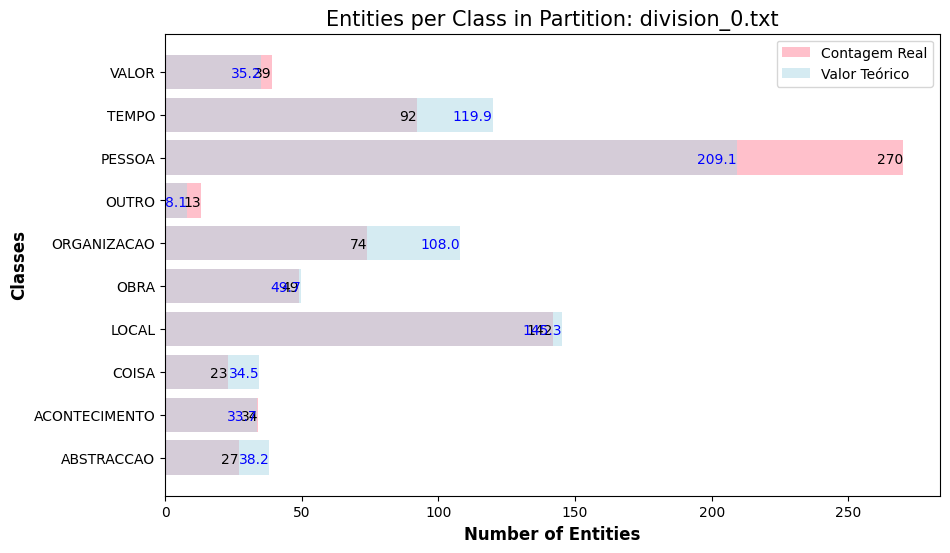

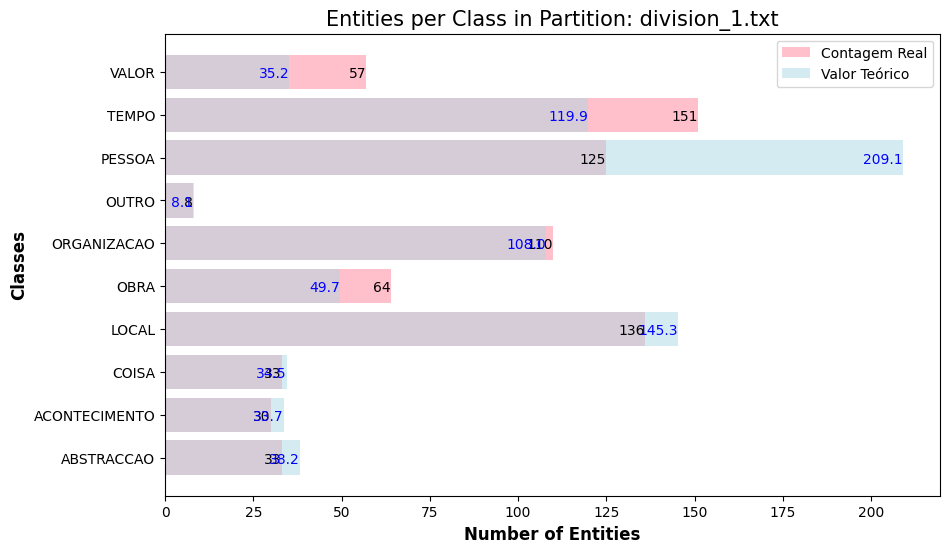

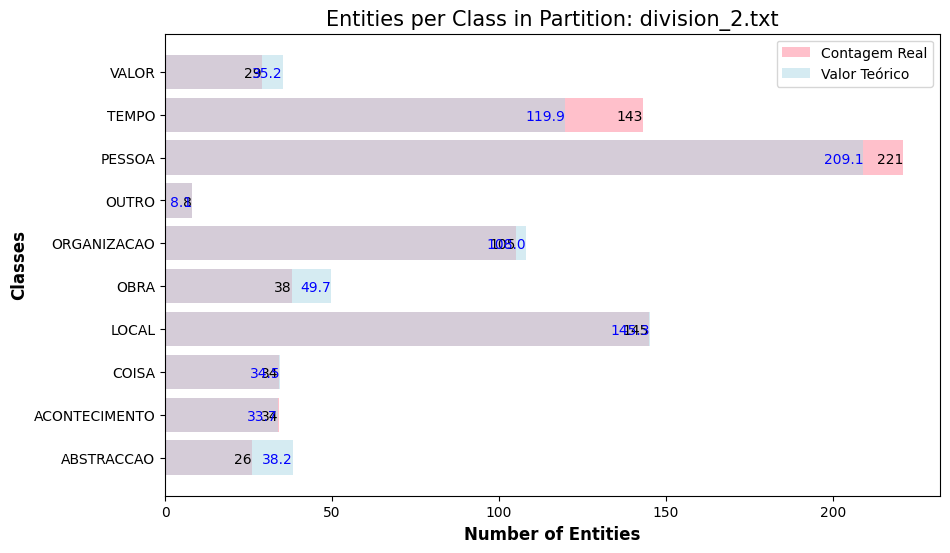

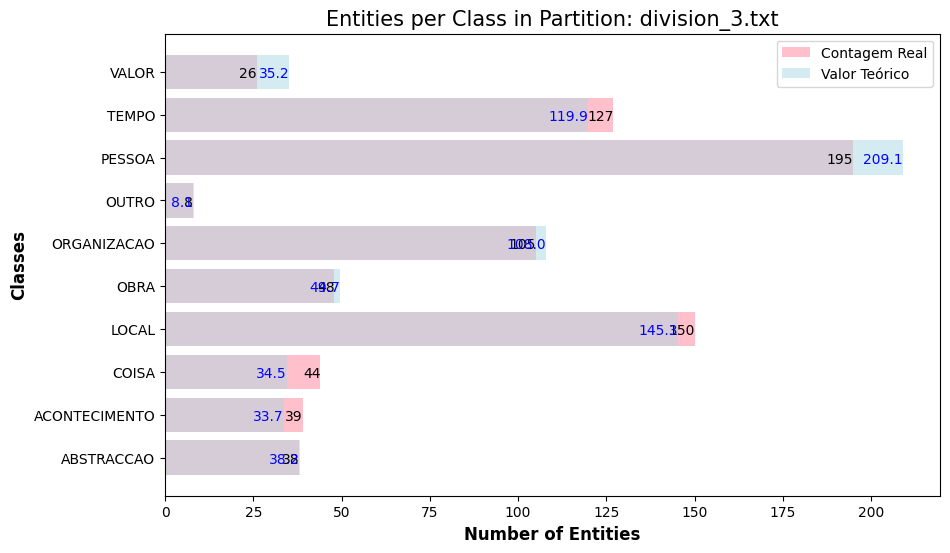

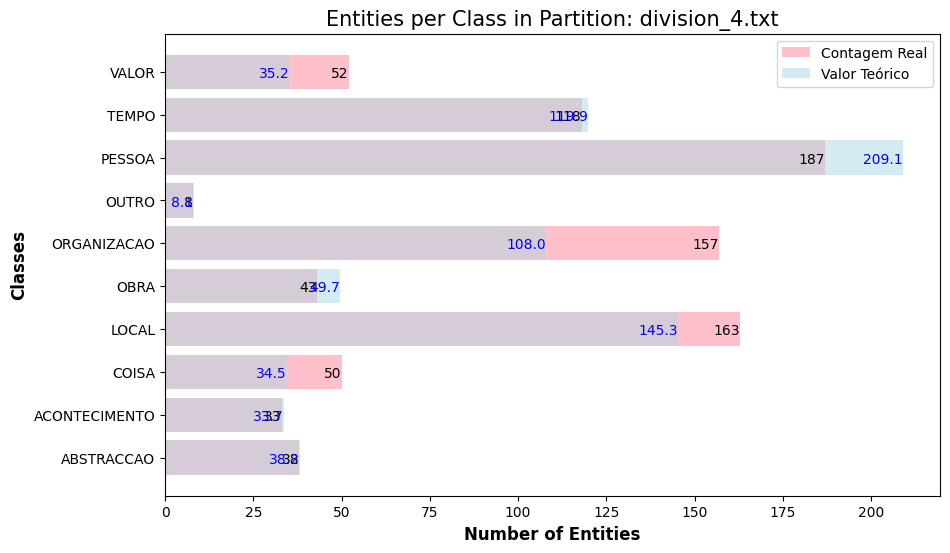

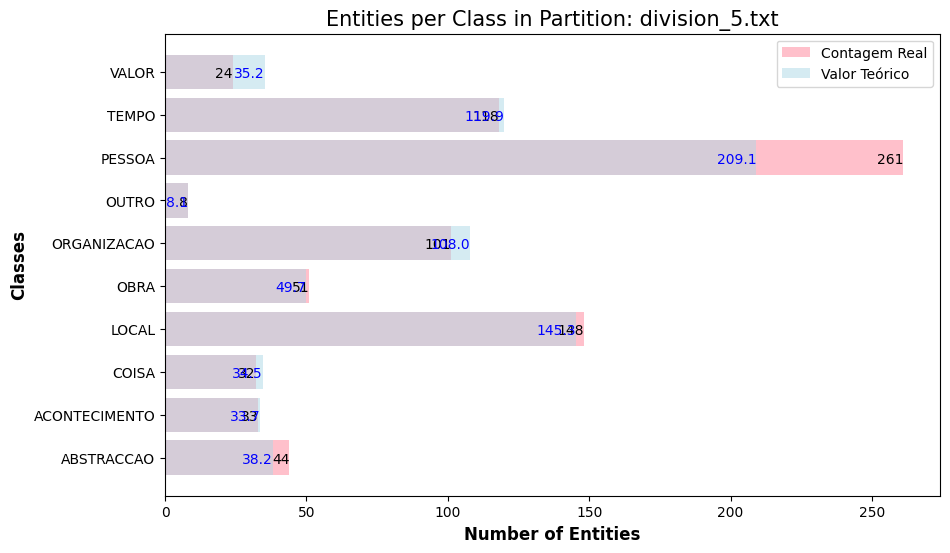

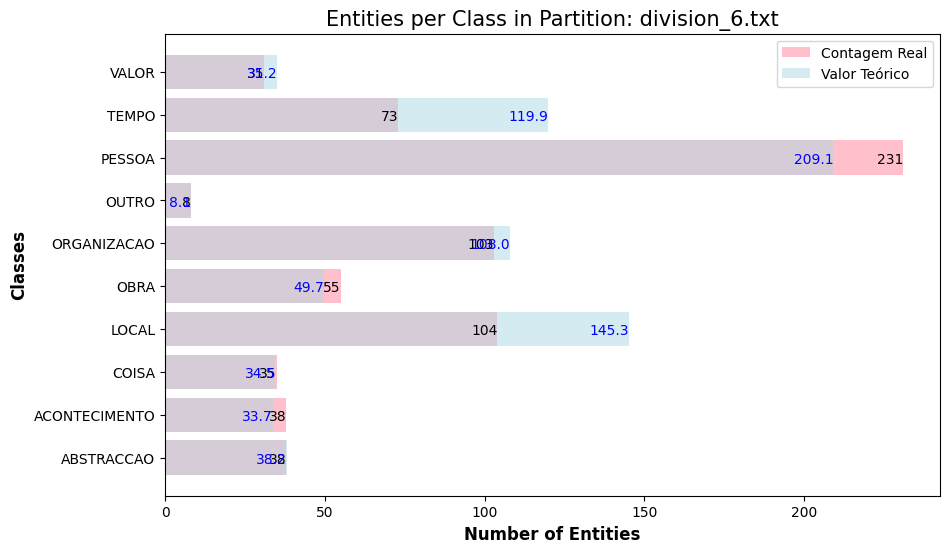

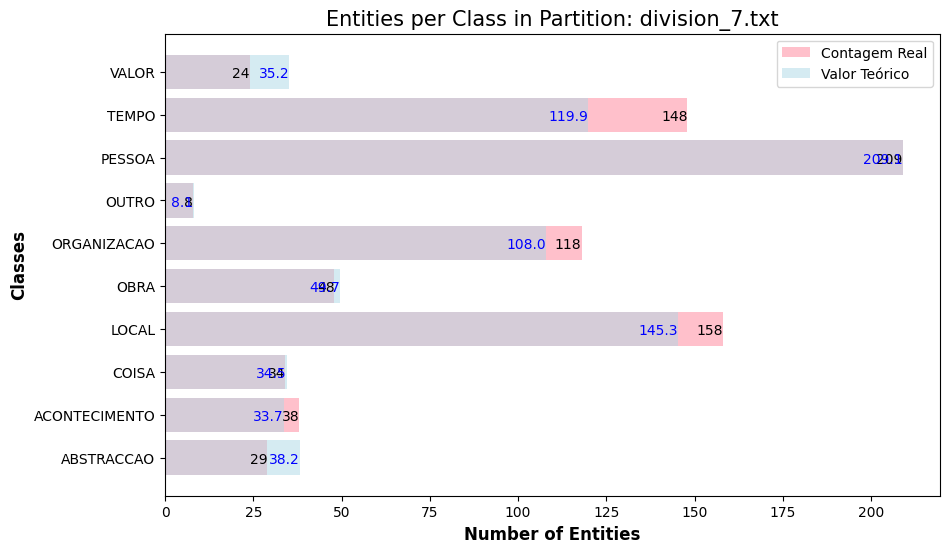

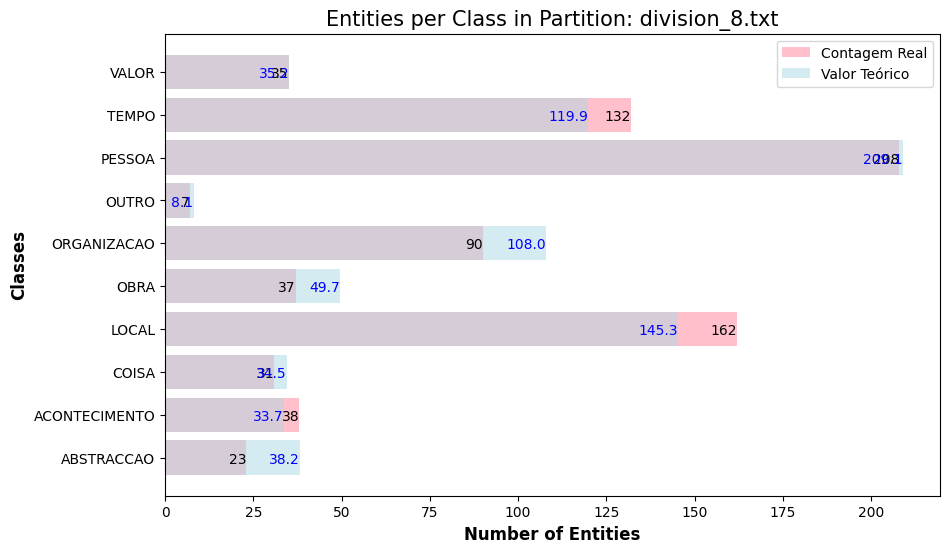

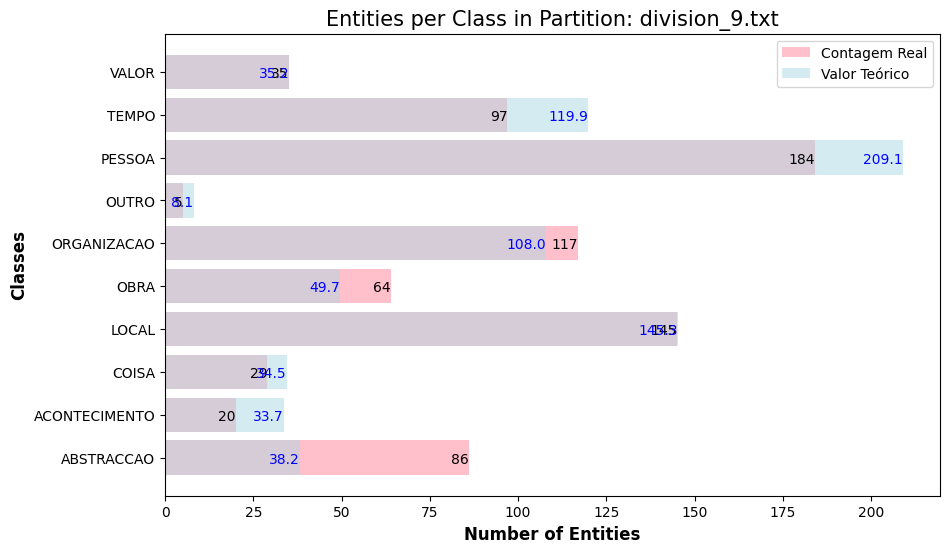

In [33]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import re

# Diretório onde as partições estão salvas
base_dir = "../Base de Dados/HAREM/divisions/second/iterative/"

number_divisions = 10

# Inicializar lista para as classes teóricas
unique_lbl_list = []

# Lista de abreviações
abbreviations = r"\b(?:Sr|S|Sra|Dr|Prof|Eng|Mme|Mestre|Vº|Vª)\.$"  # Abreviações que não devem terminar uma sentença
pattern = r"[.!?](\s|$)"  # Verifica ponto, exclamação ou interrogação seguidos de espaço ou fim da linha

# Contadores gerais
total_counts = Counter()
total_sentences_por_div = {}
total_tokens_por_div = {}

for file_name in sorted(os.listdir(base_dir)):
    if file_name.startswith("division_"):
        partition_path = os.path.join(base_dir, file_name)
        with open(partition_path, 'r', encoding='utf-8') as file:
            sentence_count = 0
            token_count = 0
            for line in file:
                line = line.strip()
                if line:
                    token_data = line.split()
                    label = token_data[-1]
                    token_count += 1  # Contando tokens
                    if label.startswith("B-"):  # Considerar apenas os rótulos com prefixo 'B-'
                        simplified_label = label.split("-")[-1]
                        unique_lbl_list.append(simplified_label)
                        total_counts[simplified_label] += 1
                    
                    # Verificar se a linha termina com ponto, exclamação ou interrogação
                    # e garantir que não seja uma abreviação
                    if re.search(pattern, line) and not re.search(abbreviations, line):
                        sentence_count += 1
            
            total_sentences_por_div[file_name] = sentence_count
            total_tokens_por_div[file_name] = token_count

# Obter classes teóricas únicas e ordenadas
classes_teoricas = sorted(set(unique_lbl_list))

# Calcular os valores teóricos dividindo as contagens totais por número de divisões
valores_teoricos = [total_counts[cls] / number_divisions for cls in classes_teoricas]

# Inicializando dicionários para armazenar contagens por partição
qtd_classes_por_div = {}
total_entidades_por_div = {}

# Iterar novamente pelas partições para calcular os valores reais
for file_name in sorted(os.listdir(base_dir)):
    if file_name.startswith("division_"):
        partition_path = os.path.join(base_dir, file_name)

        # Inicializar contador para esta partição
        labels_count = Counter()

        with open(partition_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if line:
                    token_data = line.split()
                    label = token_data[-1]
                    if label.startswith("B-"):  # Considerar apenas os rótulos com prefixo 'B-'
                        simplified_label = label.split("-")[-1]
                        labels_count[simplified_label] += 1

        # Armazenar as contagens para a partição atual
        qtd_classes_por_div[file_name] = labels_count
        total_entidades_por_div[file_name] = sum(labels_count.values())

# Calculando o total geral de todas as partições
total_entidades_geral = sum(total_entidades_por_div.values())
total_sentences_geral = sum(total_sentences_por_div.values())
total_tokens_geral = sum(total_tokens_por_div.values())

# Exibindo os totais por partição e o total geral
print("Totais de entidades, sentenças e tokens por partição:")
for div_name in total_entidades_por_div:
    print(f"  {div_name}: {total_entidades_por_div[div_name]} entidades, "
          f"{total_sentences_por_div[div_name]} sentenças, "
          f"{total_tokens_por_div[div_name]} tokens")
print(f"\nTotal geral de entidades: {total_entidades_geral}")
print(f"Total geral de sentenças: {total_sentences_geral}")
print(f"Total geral de tokens: {total_tokens_geral}\n")

# Gerando os gráficos para cada partição
for div_name, labels_count in qtd_classes_por_div.items():
    # Ordenar as contagens conforme as classes teóricas
    qtd = [labels_count.get(cls, 0) for cls in classes_teoricas]

    plt.figure(figsize=(10, 6))
    bars_real = plt.barh(classes_teoricas, qtd, color="pink", label="Contagem Real")
    bars_teorico = plt.barh(classes_teoricas, valores_teoricos, color="lightblue", alpha=0.5, label="Valor Teórico")

    # Adicionando os valores nas barras
    for i, count in enumerate(qtd):
        plt.text(count, i, str(count), va="center_baseline", ha="right", fontsize=10)

    for i, teorico in enumerate(valores_teoricos):
        if teorico > 0:
            plt.text(teorico, i, f"{teorico:.1f}", va="center_baseline", ha="right", fontsize=10, color="blue")

    plt.title(f"Entities per Class in Partition: {div_name}", fontsize=15)
    plt.xlabel("Number of Entities", fontweight="bold", fontsize=12)
    plt.ylabel("Classes", fontweight="bold", fontsize=12)

    plt.legend()

    # Salvando o gráfico
    output_path = os.path.join(base_dir, f"entities_per_class_{div_name}.png")
    plt.savefig(output_path, dpi=300, format="png", bbox_inches="tight")
    print(f"Gráfico salvo: {output_path}")

print("Todos os gráficos foram gerados e salvos com sucesso!")


Totais de entidades, sentenças e tokens por partição:
  division_0.txt: 763 entidades, 385 sentenças, 7570 tokens
  division_1.txt: 747 entidades, 263 sentenças, 7349 tokens
  division_2.txt: 783 entidades, 314 sentenças, 8113 tokens
  division_3.txt: 780 entidades, 528 sentenças, 8888 tokens
  division_4.txt: 849 entidades, 392 sentenças, 8745 tokens
  division_5.txt: 820 entidades, 404 sentenças, 7581 tokens
  division_6.txt: 716 entidades, 323 sentenças, 7555 tokens
  division_7.txt: 814 entidades, 449 sentenças, 7568 tokens
  division_8.txt: 763 entidades, 559 sentenças, 7671 tokens
  division_9.txt: 782 entidades, 360 sentenças, 9672 tokens

Total geral de entidades: 7817
Total geral de sentenças: 3977
Total geral de tokens: 80712


Imagem única salva em: ../Base de Dados/HAREM/divisions/second/iterative/entities_all_partitions_A4.png
Todos os gráficos foram gerados com sucesso!


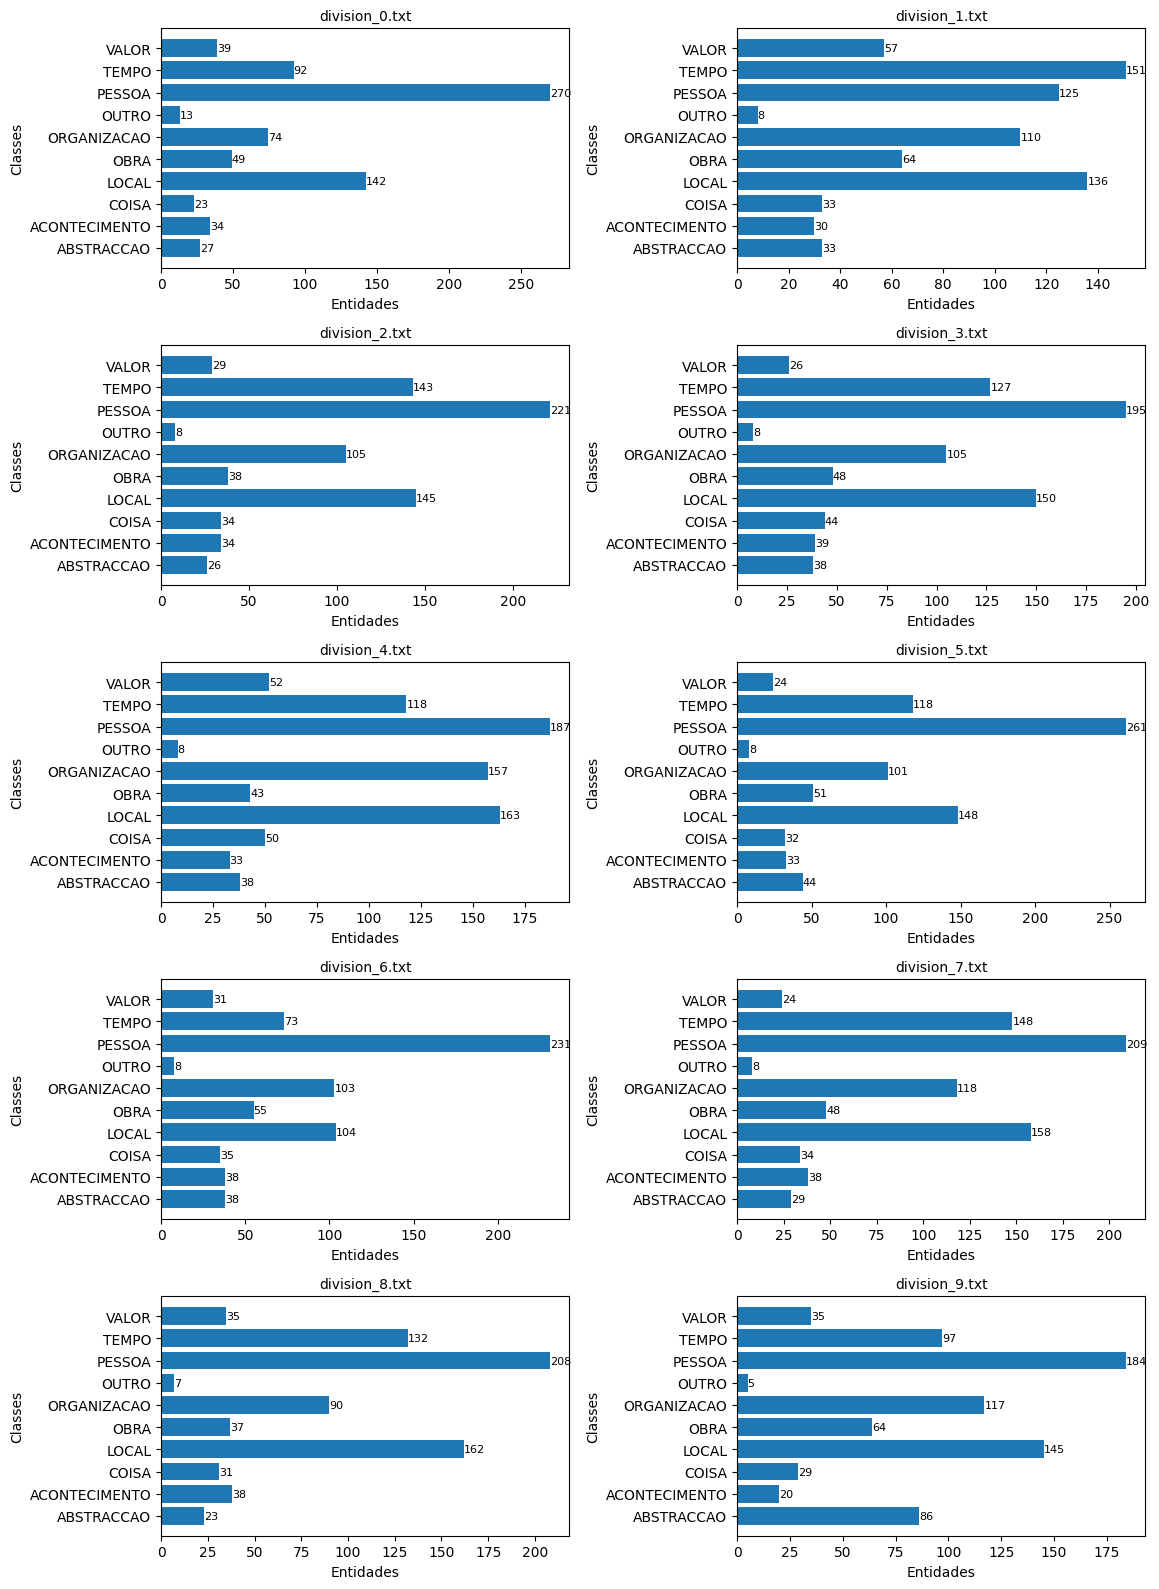

In [1]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import re

# Diretório onde as partições estão salvas
base_dir = "../Base de Dados/HAREM/divisions/second/iterative/"


number_divisions = 10

# Inicializar lista para as classes
unique_lbl_list = []

# Lista de abreviações
abbreviations = r"\b(?:Sr|S|Sra|Dr|Prof|Eng|Mme|Mestre|Vº|Vª)\.$"
pattern = r"[.!?](\s|$)"

# Contadores gerais
total_counts = Counter()
total_sentences_por_div = {}
total_tokens_por_div = {}

# ===============================
# PRIMEIRA PASSAGEM: CONTAGENS GERAIS
# ===============================
for file_name in sorted(os.listdir(base_dir)):
    partition_path = os.path.join(base_dir, file_name)

    if file_name.startswith("division_") and os.path.isfile(partition_path):
        with open(partition_path, 'r', encoding='utf-8') as file:
            sentence_count = 0
            token_count = 0

            for line in file:
                line = line.strip()
                if line:
                    token_data = line.split()
                    label = token_data[-1]
                    token_count += 1

                    if label.startswith("B-"):
                        simplified_label = label.split("-")[-1]
                        unique_lbl_list.append(simplified_label)
                        total_counts[simplified_label] += 1

                    if re.search(pattern, line) and not re.search(abbreviations, line):
                        sentence_count += 1

            total_sentences_por_div[file_name] = sentence_count
            total_tokens_por_div[file_name] = token_count

# Classes únicas ordenadas
classes_teoricas = sorted(set(unique_lbl_list))

# ===============================
# SEGUNDA PASSAGEM: CONTAGENS POR PARTIÇÃO
# ===============================
qtd_classes_por_div = {}
total_entidades_por_div = {}

for file_name in sorted(os.listdir(base_dir)):
    partition_path = os.path.join(base_dir, file_name)

    if file_name.startswith("division_") and os.path.isfile(partition_path):

        labels_count = Counter()

        with open(partition_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if line:
                    token_data = line.split()
                    label = token_data[-1]

                    if label.startswith("B-"):
                        simplified_label = label.split("-")[-1]
                        labels_count[simplified_label] += 1

        qtd_classes_por_div[file_name] = labels_count
        total_entidades_por_div[file_name] = sum(labels_count.values())

# ===============================
# TOTAIS GERAIS
# ===============================
total_entidades_geral = sum(total_entidades_por_div.values())
total_sentences_geral = sum(total_sentences_por_div.values())
total_tokens_geral = sum(total_tokens_por_div.values())

print("Totais de entidades, sentenças e tokens por partição:")
for div_name in total_entidades_por_div:
    print(f"  {div_name}: {total_entidades_por_div[div_name]} entidades, "
          f"{total_sentences_por_div[div_name]} sentenças, "
          f"{total_tokens_por_div[div_name]} tokens")

print(f"\nTotal geral de entidades: {total_entidades_geral}")
print(f"Total geral de sentenças: {total_sentences_geral}")
print(f"Total geral de tokens: {total_tokens_geral}\n")

# ===============================
# GERAR UMA ÚNICA IMAGEM A4 COM TODAS AS PARTIÇÕES
# ===============================

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(11.69, 16))
axes = axes.flatten()

for ax, (div_name, labels_count) in zip(axes, qtd_classes_por_div.items()):
    
    qtd = [labels_count.get(cls, 0) for cls in classes_teoricas]

    ax.barh(classes_teoricas, qtd)

    for i, count in enumerate(qtd):
        if count > 0:
            ax.text(count, i, str(count), va="center", fontsize=8)

    ax.set_title(div_name, fontsize=10)
    ax.set_xlabel("Entidades")
    ax.set_ylabel("Classes")

plt.tight_layout()

output_path = os.path.join(base_dir, "entities_all_partitions_A4.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

print(f"\nImagem única salva em: {output_path}")
print("Todos os gráficos foram gerados com sucesso!")

Totais de entidades, sentenças e tokens por partição:
  division_0.txt: 763 entidades, 385 sentenças, 7570 tokens
  division_1.txt: 747 entidades, 263 sentenças, 7349 tokens
  division_2.txt: 783 entidades, 314 sentenças, 8113 tokens
  division_3.txt: 780 entidades, 528 sentenças, 8888 tokens
  division_4.txt: 849 entidades, 392 sentenças, 8745 tokens
  division_5.txt: 820 entidades, 404 sentenças, 7581 tokens
  division_6.txt: 716 entidades, 323 sentenças, 7555 tokens
  division_7.txt: 814 entidades, 449 sentenças, 7568 tokens
  division_8.txt: 763 entidades, 559 sentenças, 7671 tokens
  division_9.txt: 782 entidades, 360 sentenças, 9672 tokens

Total geral de entidades: 7817
Total geral de sentenças: 3977
Total geral de tokens: 80712


Imagem única salva em: ../Base de Dados/HAREM/divisions/second/iterative/entities_all_partitions_A4.png
Todos os gráficos foram gerados com sucesso!


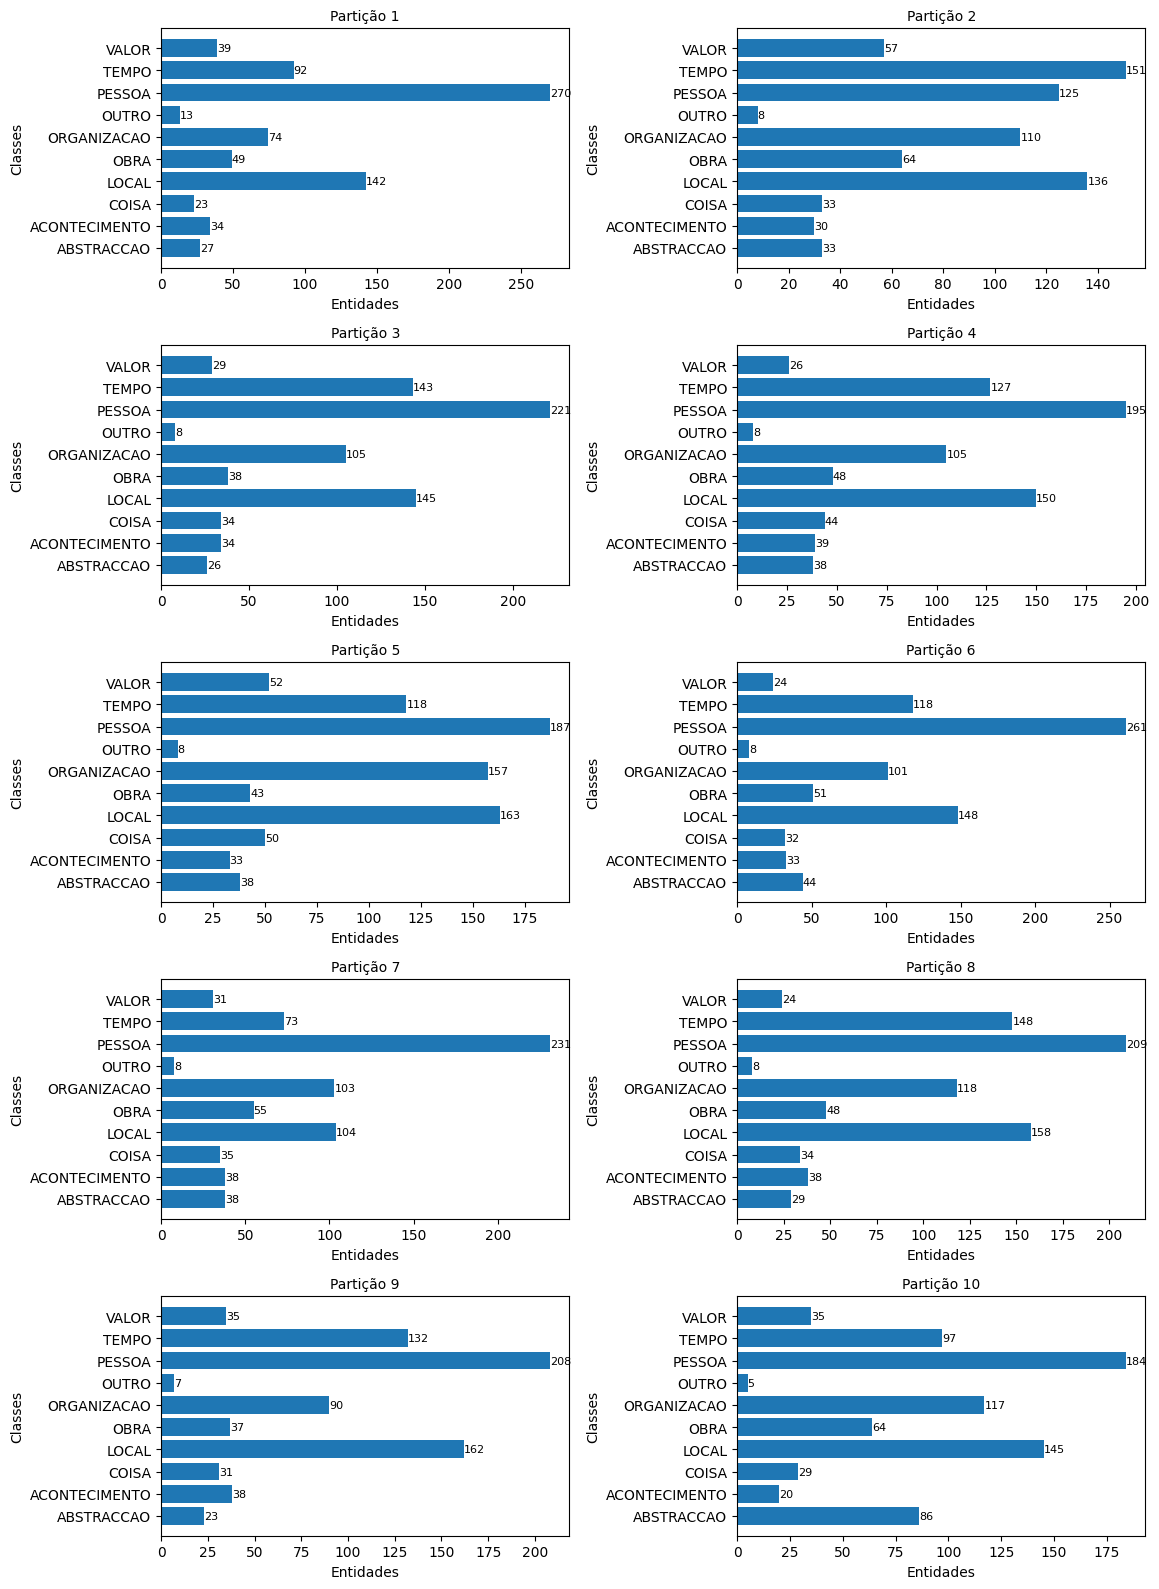

In [1]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import re

# Diretório onde as partições estão salvas
base_dir = "../Base de Dados/HAREM/divisions/second/iterative/"

# Inicializar lista para as classes
unique_lbl_list = []

# Lista de abreviações
abbreviations = r"\b(?:Sr|S|Sra|Dr|Prof|Eng|Mme|Mestre|Vº|Vª)\.$"
pattern = r"[.!?](\s|$)"

# Contadores gerais
total_counts = Counter()
total_sentences_por_div = {}
total_tokens_por_div = {}

# ===============================
# LISTAR E ORDENAR PARTIÇÕES
# ===============================
division_files = sorted(
    [f for f in os.listdir(base_dir) if f.startswith("division_")],
    key=lambda x: int(x.split("_")[1].split(".")[0])
)

# ===============================
# PRIMEIRA PASSAGEM: CONTAGENS GERAIS
# ===============================
for file_name in division_files:

    partition_path = os.path.join(base_dir, file_name)

    with open(partition_path, 'r', encoding='utf-8') as file:
        sentence_count = 0
        token_count = 0

        for line in file:
            line = line.strip()

            if line:
                token_data = line.split()
                label = token_data[-1]

                token_count += 1

                if label.startswith("B-"):
                    simplified_label = label.split("-")[-1]
                    unique_lbl_list.append(simplified_label)
                    total_counts[simplified_label] += 1

                if re.search(pattern, line) and not re.search(abbreviations, line):
                    sentence_count += 1

        total_sentences_por_div[file_name] = sentence_count
        total_tokens_por_div[file_name] = token_count

# Classes únicas ordenadas
classes_teoricas = sorted(set(unique_lbl_list))

# ===============================
# SEGUNDA PASSAGEM: CONTAGENS POR PARTIÇÃO
# ===============================
qtd_classes_por_div = {}
total_entidades_por_div = {}

for file_name in division_files:

    partition_path = os.path.join(base_dir, file_name)

    labels_count = Counter()

    with open(partition_path, 'r', encoding='utf-8') as file:

        for line in file:
            line = line.strip()

            if line:
                token_data = line.split()
                label = token_data[-1]

                if label.startswith("B-"):
                    simplified_label = label.split("-")[-1]
                    labels_count[simplified_label] += 1

    qtd_classes_por_div[file_name] = labels_count
    total_entidades_por_div[file_name] = sum(labels_count.values())

# ===============================
# TOTAIS GERAIS
# ===============================
total_entidades_geral = sum(total_entidades_por_div.values())
total_sentences_geral = sum(total_sentences_por_div.values())
total_tokens_geral = sum(total_tokens_por_div.values())

print("Totais de entidades, sentenças e tokens por partição:")

for div_name in division_files:
    print(
        f"  {div_name}: {total_entidades_por_div[div_name]} entidades, "
        f"{total_sentences_por_div[div_name]} sentenças, "
        f"{total_tokens_por_div[div_name]} tokens"
    )

print(f"\nTotal geral de entidades: {total_entidades_geral}")
print(f"Total geral de sentenças: {total_sentences_geral}")
print(f"Total geral de tokens: {total_tokens_geral}\n")

# ===============================
# GERAR UMA ÚNICA IMAGEM A4 COM TODAS AS PARTIÇÕES
# ===============================
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(11.69, 16))
axes = axes.flatten()

for ax, div_name in zip(axes, division_files):

    labels_count = qtd_classes_por_div[div_name]

    qtd = [labels_count.get(cls, 0) for cls in classes_teoricas]

    ax.barh(classes_teoricas, qtd)

    for i, count in enumerate(qtd):
        if count > 0:
            ax.text(count, i, str(count), va="center", fontsize=8)

    # division_0.txt -> Partição 1
    num_div = int(div_name.split("_")[1].split(".")[0]) + 1

    ax.set_title(f"Partição {num_div}", fontsize=10)
    ax.set_xlabel("Entidades")
    ax.set_ylabel("Classes")

plt.tight_layout()

output_path = os.path.join(base_dir, "entities_all_partitions_A4.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

print(f"\nImagem única salva em: {output_path}")
print("Todos os gráficos foram gerados com sucesso!")